# Quantum Amplitude Estimation Engine

Prices options using three QAE algorithms and compares them against Black Scholes and Monte Carlo.

**Algorithms implemented:**
- **Classical QAE** - QPE-based, deep circuits, exact in statevector simulation
- **IQAE** - Iterative QAE: shallow circuits, hardware-friendly, O(1/ε) oracle complexity
- **MLQAE** - Maximum-Likelihood QAE: fixed shot schedule + MLE post-processing

**Studies included:**
1. Single strike pricing - all methods vs BS vs market
2. Discretisation accuracy - how n_qubits affects grid resolution
3. Three way convergence - QAE O(1/ε) vs MC O(1/√N) on one plot
4. Noise sensitivity - how depolarising noise degrades QAE accuracy
5. Full strike sweep - QAE prices across all liquid strikes

All quantum circuits run on *classical simulators* (Aer). The O(1/ε) advantage is asymptotic and theoretical. The noise study and break-even analysis quantify why current NISQ hardware cannot yet realise this advantage.

# 1. Imports & Path Setup

In [2]:
import sys, os, json, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec
import qiskit, qiskit_aer, qiskit_finance

# ── PATH CONFIG ────────────────────────────────────────────────────────────────
PROJECT_ROOT = "."     # folder containing params.py, black_scholes.py,
                        # monte_carlo.py, quantum_ae.py
DATA_DIR     = os.path.join(PROJECT_ROOT, "data")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
# ───────────────────────────────────────────────────────────────────────────────

from params import SharedParameters
from BlackScholes import bs_price
from MonteCarlo import plainMC, antitheticMC, controlMC, quasiMC
from QuantumAE import classicalQAE, iterativeQAE, mlQAE, qaeConvergence, discretisation_report, noise_impact_study, QAEResult

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})

COLORS = {
    'bs'            : '#222222',
    'plain_mc'      : '#378ADD',
    'antithetic_mc' : '#6BAED6',
    'control_var'   : '#1D9E75',
    'quasi_mc'      : '#8B49C2',
    'classical_qae' : '#D85A30',
    'iqae'          : '#E8831A',
    'mlqae'         : '#B8290A',
    'market'        : '#BA7517',
    'spot'          : '#888888',
    'noise'         : '#CC3333',
}

print("Imports OK.")

Imports OK.


# 2. List Available Snapshots

In [3]:
def list_snapshots(data_dir=DATA_DIR):
    if not os.path.exists(data_dir):
        print(f"Data directory not found: {os.path.abspath(data_dir)}")
        return []
    meta_files = sorted(f for f in os.listdir(data_dir) if f.endswith("_meta.json"))
    if not meta_files:
        print("No Snapshots found. Please run OptionsData.ipynb and download options data")
        return []
    slugs = []
    print(f"{'#':<3}  {'Slug':<48}  {'Ticker':<6}  {'Expiry':<12}  "
          f"{'Spot':>7}  {'DTE':>5}  {'T':>6}")
    print("─" * 100)
    for i, mf in enumerate(meta_files):
        with open(os.path.join(data_dir, mf)) as f:
            m = json.load(f)
        slug = mf.replace("_meta.json", "")
        slugs.append(slug)
        print(f"{i:<3}  {slug:<48}  {m['ticker']:<6}  {m['expiry']:<12}  "
              f"${m['spot']:>6.2f}  {m.get('dte','?'):>5}  {m['T']:>6.4f}")
    return slugs

available_slugs = list_snapshots()

#    Slug                                              Ticker  Expiry           Spot    DTE       T
────────────────────────────────────────────────────────────────────────────────────────────────────
0    MSFT_2026-07-10_20260602_0214                     MSFT    2026-07-10    $460.52     37  0.1014


# 3. Select Snapshot & Configure

QAE Specific notes:

- `N_Qubits = 5` -> 32 grid points. Good accuracy/speed balance for demo.
- `N_Qubits = 7` -> 128 grid points. Better accuracy, slower circuit build.
- Circuits grow exponentially with n_qubits - stay <= 7 in simulation.
- `BACKEND = 'statevector'` is exact and fastest for noiseless comparison.
- `BACKEND = 'shot'` simulates realistic shot noise.
- `BACKEND = 'noisy'` adds depolarising + readout errors.

In [4]:
# SNAPSHOT
SLUG = ""       # Paste slug or leave empty if using index
SLUG_INDEX = 0

# QAE CONFIG
N_QUBITS = 5            # state prep qubits (gird = 2**N_QUBITS points)
N_AE_QUBITS = 5         # evaluation qubits for classical QAE
EPSILON = 0.01          # IQAE target amplitude precisison
BACKEND = "shot"        # 'statevector / noisy / shot
NOISE_LEVEL = 0.001     # depolarising error rate (use for noisy backend)
Q = 0.0                 # continous dividend yield
N_SHOTS = 4096          # shots for shot/noisy backend

# CONVERGENCE STUDY
EPS_MIN = 0.001     
EPS_MAX = 0.1
N_EPS_PTS = 10          # points in epsilon grid
QAE_REPEATS = 3         # independent trials per epsilon

# NOISE STUDY
NOISE_MIN = 1e-4
NOISE_MAX = 0.05
N_NOISE_PTS = 8
NOISE_RPTS = 3

if not SLUG:
    if not available_slugs:
        raise RuntimeError("No Snapshots found. Please run OptionsData.ipynb and download options data")
    SLUG = available_slugs[SLUG_INDEX]
    
with open(os.path.join(DATA_DIR, f"{SLUG}_meta.json")) as f:
    meta = json.load(f)
    
calls_mkt = pd.read_csv(os.path.join(DATA_DIR, f"{SLUG}_calls.csv"))
puts_mkt = pd.read_csv(os.path.join(DATA_DIR, f"{SLUG}_puts.csv"))

S = float(meta['spot'])
r = float(meta['r'])
T = float(meta['T'])
TICKER = meta['ticker']
EXPIRY = meta['expiry']
DTE = meta.get('dte', round(T*365))

# Load prior engine results if available
bs_calls = pd.read_csv(os.path.join(DATA_DIR, f"{SLUG}_bs_calls.csv")) \
           if os.path.exists(os.path.join(DATA_DIR, f"{SLUG}_bs_calls.csv")) else None
mc_calls = pd.read_csv(os.path.join(DATA_DIR, f"{SLUG}_mc_calls.csv")) \
           if os.path.exists(os.path.join(DATA_DIR, f"{SLUG}_mc_calls.csv")) else None
mc_conv  = pd.read_csv(os.path.join(DATA_DIR, f"{SLUG}_mc_convergence.csv")) \
           if os.path.exists(os.path.join(DATA_DIR, f"{SLUG}_mc_convergence.csv")) else None
           
print(f"Snapshot  : {SLUG}")
print(f"Ticker    : {TICKER}  |  Expiry: {EXPIRY}  ({DTE} DTE)")
print(f"Spot      : ${S:.2f}  |  r: {r:.2%}  |  T: {T:.4f}y")
print(f"BS results: {'loaded' if bs_calls is not None else 'not found'}")
print(f"MC results: {'loaded' if mc_calls is not None else 'not found'}")
print(f"MC conv   : {'loaded' if mc_conv is not None else 'not found'}")
print(f"\nQAE config: n_qubits={N_QUBITS}  backend={BACKEND}  epsilon={EPSILON}  noise={NOISE_LEVEL}")
print(f"Grid pts  : {2**N_QUBITS} (2^{N_QUBITS})")

Snapshot  : MSFT_2026-07-10_20260602_0214
Ticker    : MSFT  |  Expiry: 2026-07-10  (37 DTE)
Spot      : $460.52  |  r: 3.60%  |  T: 0.1014y
BS results: loaded
MC results: loaded
MC conv   : loaded

QAE config: n_qubits=5  backend=shot  epsilon=0.01  noise=0.001
Grid pts  : 32 (2^5)


# Discretisation Study

Before running quantum circuits, understand how many qubits are needed for log normal grid to be accuate. This isolates grid error from estimation error.

ATM call: K=460.00  σ=36.91%  BS=22.6394

Discretisation study (n_qubits = 3 -> 9)...

  n_qubits   grid pts   QAE price    |vs BS|    % error   
  ───────────────────────────────────────────────────────
  3          8          69.345057    46.705700  206.303   
  4          16         29.884816    7.245460   32.004    
  5          32         23.418918    0.779561   3.443      recommended
  6          64         22.869219    0.229863   1.015     
  7          128        22.703291    0.063934   0.282     
  8          256        22.637796    0.001561   0.007     
  9          512        22.642331    0.002974   0.013     


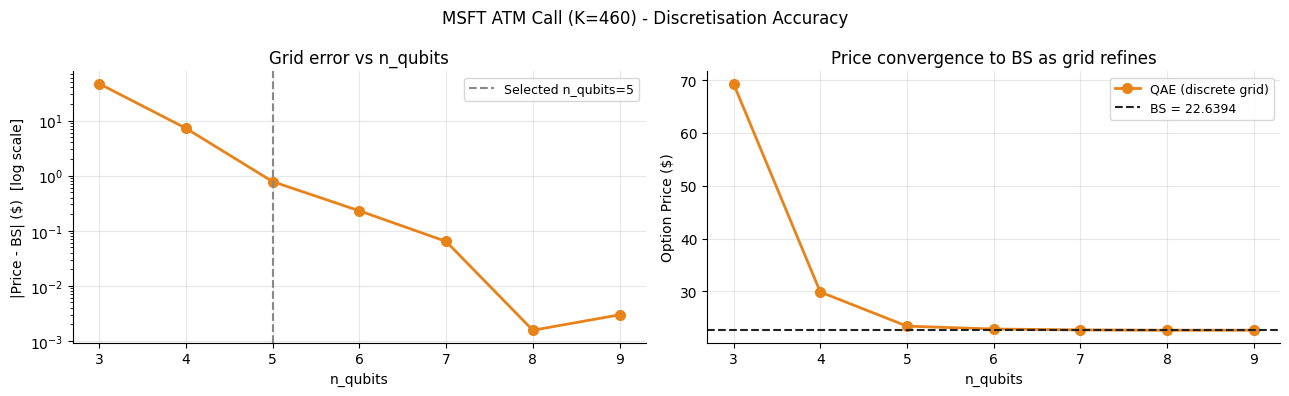

In [12]:
# Use ATM strke for study
atm_row = calls_mkt.iloc[(calls_mkt['strike'] - S).abs().argsort().iloc[0]]
K_atm = float(atm_row['strike'])
sigma_atm = float(atm_row['impliedVolatility'])
p_atm = SharedParameters(S=S, K=K_atm, r=r, sigma=sigma_atm, T=T)
bs_ref = bs_price(p_atm, 'call', q=Q)

print(f"ATM call: K={K_atm:.2f}  σ={sigma_atm:.2%}  BS={bs_ref:.4f}")
print(f"\nDiscretisation study (n_qubits = 3 -> 9)...")

qubit_range = list(range(3, 10))
disc = {'n_qubits': [], 'n_points': [], 'prices': [], 'errors': [], 'bs_ref': bs_ref}

for nq in qubit_range:
    rep = discretisation_report(p_atm, n_qubits=nq, q=Q, option_type='call')
    disc['n_qubits'].append(nq)
    disc['n_points'].append(rep['n_points'])
    disc['prices'].append(rep['discretised_price'])
    disc['errors'].append(rep['disc_error'])

print(f"\n  {'n_qubits':<10} {'grid pts':<10} {'QAE price':<12} {'|vs BS|':<10} {'% error':<10}")
print("  " + "─" * 55)

for i, nq in enumerate(disc['n_qubits']):
    pct = disc['errors'][i] / bs_ref * 100
    flag = " recommended" if nq==N_QUBITS else ""
    print(f"  {nq:<10} {disc['n_points'][i]:<10} {disc['prices'][i]:<12.6f} {disc['errors'][i]:<10.6f} {pct:<10.3f}{flag}")
    
# Plotting
fig, axes = plt.subplots(1,2, figsize=(13,4))
fig.suptitle(f"{TICKER} ATM Call (K={K_atm:.0f}) - Discretisation Accuracy", fontsize=12)

ax = axes[0]
ax.semilogy(disc['n_qubits'], disc['errors'], 'o-', color=COLORS['iqae'], lw=2, markersize=7)
ax.axvline(N_QUBITS, color=COLORS['spot'], lw=1.5, linestyle='--', label=f'Selected n_qubits={N_QUBITS}')
ax.set_xlabel('n_qubits'); ax.set_ylabel('|Price - BS| ($)  [log scale]')
ax.set_title('Grid error vs n_qubits'); ax.legend(fontsize=9)
ax.set_xticks(disc['n_qubits'])

ax = axes[1]
ax.plot(disc['n_qubits'], disc['prices'], 'o-', color=COLORS['iqae'], lw=2, markersize=7, label='QAE (discrete grid)')
ax.axhline(bs_ref, color=COLORS['bs'], lw=1.5, linestyle='--', label=f'BS = {bs_ref:.4f}')
ax.set_xlabel('n_qubits'); ax.set_ylabel('Option Price ($)')
ax.set_title('Price convergence to BS as grid refines')
ax.legend(fontsize=9); ax.set_xticks(disc['n_qubits'])

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, f"{SLUG}_qae_discretisation.png"), dpi=150, bbox_inches='tight')
plt.show()